# 01 · Data acquisition

Gets **LLVIP** (15 488 pedestrian pairs, mostly at night) and **M3FD** (4 200 pairs, six classes) onto the machine and checks they are complete. Both are for non-commercial research only, so do not make your Kaggle copies public.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot`, plus LLVIP and M3FD (see below) |
| **Expected runtime** | a few minutes (longer if downloading) |
| **Produces** | verified raw datasets |

## How to get the data onto Kaggle

**Option A (recommended).** Download the official archives on your computer and upload each as a **private**
Kaggle dataset (*Datasets → New Dataset → upload the zip*; Kaggle unzips it). Then attach both here
(*Add Input → Your Work*).

* LLVIP: <https://bupt-ai-cz.github.io/LLVIP/>, with the February 2023 corrected annotations.
* M3FD: the *M3FD_Detection* part (`Vis/`, `Ir/`, `Annotation/`) of <https://github.com/JinyuanLiu-CV/TarDAL>.

**Option B.** Attach a public Kaggle copy (search for "LLVIP" / "M3FD") with the official folder layout and
the corrected LLVIP labels.

**Option C.** Paste a public Google Drive link or file ID below and download inside this notebook.

Datasets are found by folder layout, so their names do not matter.

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


In [2]:
LLVIP_GDRIVE = ""
M3FD_GDRIVE = ""
if LLVIP_GDRIVE:
    pipeline.download_gdrive(LLVIP_GDRIVE, env.raw / "llvip")
if M3FD_GDRIVE:
    pipeline.download_gdrive(M3FD_GDRIVE, env.raw / "m3fd")

## Where are they?

In [3]:
found = {name: pipeline.locate_raw(name, env) for name in ("llvip", "m3fd")}
for name, p in found.items():
    print(f"{name:6s} -> {p if p else 'NOT FOUND: attach it as an input (see the options above)'}")

llvip  -> C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\raw\llvip\LLVIP
m3fd   -> C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\raw\m3fd


## Are they complete?

Counts per folder, complete pairs, and one parsed annotation to check the class names.

In [4]:
from cffm.data import M3FD_NAMES, _parse_voc

def report_llvip(root):
    for split in ("train", "test"):
        vis = sorted((root / "visible" / split).glob("*.jpg"))
        ir = {p.name for p in (root / "infrared" / split).glob("*.jpg")}
        ann = {p.stem for p in (root / "Annotations").glob("*.xml")}
        paired = [v for v in vis if v.name in ir and v.stem in ann]
        print(f"LLVIP {split:5s}: {len(vis)} visible, {len(ir)} infrared, {len(paired)} complete pairs")
    x = next((root / "Annotations").glob("*.xml"))
    print("sample annotation", x.name, _parse_voc(x, ["person"])[:3])

def report_m3fd(root):
    from cffm.data import _find_dir
    vis, ir, ann = _find_dir(root, ["Vis", "visible"]), _find_dir(root, ["Ir", "infrared"]), \
        _find_dir(root, ["Annotation", "Annotations", "Labels"])
    nv, ni, na = (len(list(d.iterdir())) for d in (vis, ir, ann))
    print(f"M3FD: {nv} visible, {ni} infrared, {na} annotations")
    x = next(ann.glob("*.xml"))
    print("sample annotation", x.name, _parse_voc(x, M3FD_NAMES)[:3])

if found["llvip"]: report_llvip(found["llvip"])
if found["m3fd"]: report_m3fd(found["m3fd"])

LLVIP train: 12025 visible, 12025 infrared, 12025 complete pairs


LLVIP test : 3463 visible, 3463 infrared, 3463 complete pairs
sample annotation 010001.xml [(0, 287.0, 428.0, 351.0, 662.0), (0, 351.0, 391.0, 424.0, 642.0), (0, 466.0, 367.0, 550.0, 614.0)]


M3FD: 4200 visible, 4200 infrared, 4200 annotations
sample annotation 00000.xml [(0, 46.0, 372.0, 82.0, 478.0), (0, 289.0, 380.0, 314.0, 450.0), (0, 271.0, 383.0, 286.0, 411.0)]


## One pair from each

If the two images do not show the same scene, the pairing is wrong.

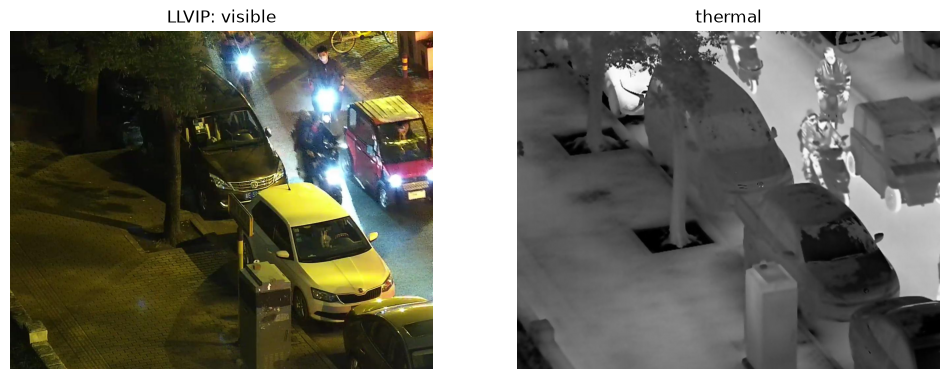

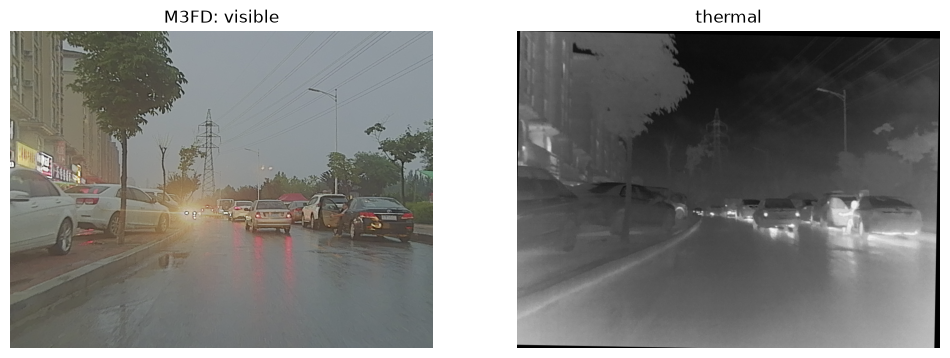

In [5]:
import cv2, matplotlib.pyplot as plt
from cffm.data import _find_dir

def show_raw_pair(vis_path, ir_path, title):
    v, i = cv2.imread(str(vis_path))[..., ::-1], cv2.imread(str(ir_path), cv2.IMREAD_GRAYSCALE)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].imshow(v); ax[0].set_title(f"{title}: visible"); ax[1].imshow(i, cmap="gray"); ax[1].set_title("thermal")
    for a in ax: a.axis("off")
    plt.show()

if found["llvip"]:
    v = sorted((found["llvip"] / "visible" / "test").glob("*.jpg"))[100]
    show_raw_pair(v, found["llvip"] / "infrared" / "test" / v.name, "LLVIP")
if found["m3fd"]:
    vd, idr = _find_dir(found["m3fd"], ["Vis", "visible"]), _find_dir(found["m3fd"], ["Ir", "infrared"])
    v = sorted(vd.iterdir())[50]
    show_raw_pair(v, next(idr.glob(v.stem + ".*")), "M3FD")